# Email / SMS Spam Detection with NLP

**Track:** Data Science &nbsp;|&nbsp; **Task:** 4 — Email Spam Detection with Machine Learning
**Author:** **Youssef Laaroussi** &nbsp;|&nbsp; **Program:** Oasis Infobyte SIP

## Objective

Build a binary NLP classifier that distinguishes spam messages from
legitimate ("ham") messages based on their text content.

## Dataset

**Source:** SMS Spam Collection — publicly available on Kaggle and the UCI
Machine Learning Repository (search "SMS Spam Collection Dataset" on
kaggle.com, or use the CSV shipped alongside this notebook).

- **Rows (raw):** 5,572 messages
- **Columns (raw):** `v1` (label: ham/spam), `v2` (message text), plus three
  mostly-empty `Unnamed` columns caused by a CSV export issue (explained and
  fixed in Section 3).

## ✅ Task Checklist — Verified Mapping

| # | Checklist item | Where it's done |
|---|---|---|
| 1 | Download a suitable dataset | Section 2 |
| 2 | Data loading and class distribution check | Section 3 |
| 3 | Text preprocessing: lowercase, punctuation removal, stopword removal, lemmatization | Section 4 |
| 4 | Feature extraction using TF-IDF (with explanation) | Section 5 |
| 5 | Train/test split | Section 6 |
| 6 | Train at least 2 classifiers (Multinomial NB + alternative) | Section 7 |
| 7 | Evaluation: accuracy, precision, recall, F1, confusion matrix | Section 8 |
| 8 | Discussion: why recall matters for spam detection | Section 9 |
| 9 | Bonus: WordCloud for spam and ham | Section 10 |
| 10 | Clean, commented Jupyter Notebook | Throughout |

## Table of Contents
1. [Environment Setup](#1)
2. [Data Sourcing & Loading](#2)
3. [Data Cleaning & Class Distribution](#3)
   - 3.1 [Initial Inspection](#31)
   - 3.2 [Fixing a CSV Export Artifact](#32)
   - 3.3 [Column Cleanup & Duplicate Removal](#33)
   - 3.4 [Class Distribution Check](#34)
4. [Text Preprocessing Pipeline](#4)
5. [Feature Extraction: TF-IDF](#5)
6. [Train / Test Split](#6)
7. [Model Training](#7)
8. [Model Evaluation](#8)
9. [Discussion: Why Recall Matters for Spam Detection](#9)
10. [Bonus: WordCloud Visualisations](#10)
11. [Conclusion](#11)
12. [References](#12)


<a id='1'></a>
## 1. Environment Setup & Imports

In [1]:
# Core data handling
import re
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from wordcloud import WordCloud

# NLP preprocessing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# One-time NLTK data downloads (safe to re-run; skips already-downloaded data)
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

# Feature extraction & modelling
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Reproducibility & display settings
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100

print("Libraries imported and NLTK data ready.")


Libraries imported and NLTK data ready.


<a id='2'></a>
## 2. Data Sourcing & Loading

**Checklist item: "Download a suitable dataset."**

The dataset was sourced from Kaggle / the UCI Machine Learning Repository
("SMS Spam Collection"). To keep this notebook self-contained on Google
Colab, the CSV (`spam.csv`) is shipped alongside it — place it in the same
folder before running. If it isn't found, the cell below automatically opens
a Colab upload widget.

The file is read with `encoding="latin-1"` because it contains characters
(curly quotes, £ signs) that are not valid UTF-8.

In [2]:
DATA_PATH = "spam.csv"

try:
    raw_df = pd.read_csv(DATA_PATH, encoding="latin-1")
    print(f"Loaded '{DATA_PATH}' from the local working directory.")
except FileNotFoundError:
    try:
        from google.colab import files
        print(f"'{DATA_PATH}' not found locally — please upload it now.")
        uploaded = files.upload()
        DATA_PATH = list(uploaded.keys())[0]
        raw_df = pd.read_csv(DATA_PATH, encoding="latin-1")
    except ImportError:
        raise FileNotFoundError(
            f"Could not find '{DATA_PATH}'. Download 'spam.csv' (SMS Spam "
            "Collection) from Kaggle and place it next to this notebook."
        )

print(f"Rows x Columns (raw): {raw_df.shape}")
raw_df.head()


Loaded 'spam.csv' from the local working directory.
Rows x Columns (raw): (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


<a id='3'></a>
## 3. Data Cleaning & Class Distribution

<a id='31'></a>
### 3.1 Initial Inspection

In [3]:
print(f"Shape: {raw_df.shape[0]} rows x {raw_df.shape[1]} columns\n")
raw_df.info()


Shape: 5572 rows x 5 columns

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


<a id='32'></a>
### 3.2 Fixing a CSV Export Artifact

**Checklist item: "Data loading..." (handling a real data-quality issue found
during loading).**

Three columns (`Unnamed: 2/3/4`) are almost entirely empty. Inspecting the
rows where they ARE populated shows why: some original messages contain
commas that were not properly escaped when this CSV was exported, so the
message text got split across extra columns instead of staying in `v2`.
Rather than simply discarding this information, the fragments are
rejoined so the affected messages are not left truncated.

In [4]:
fragment_cols = ["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"]
affected_mask = raw_df[fragment_cols].notna().any(axis=1)
print(f"Messages affected by the comma-splitting CSV issue: {affected_mask.sum()} "
      f"out of {len(raw_df)} ({affected_mask.sum() / len(raw_df) * 100:.1f}%)")

# Example of the problem, before fixing it
example = raw_df[affected_mask].iloc[0]
print("\nExample BEFORE fix:")
print("  v2 (truncated):", repr(example["v2"]))
print("  Unnamed: 2:    ", repr(example["Unnamed: 2"]))

# Fix: rejoin all non-null text fragments for each row with a comma
# (the character that caused the original split), reconstructing the message.
def rebuild_message(row):
    parts = [row["v2"]] + [row[c] for c in fragment_cols]
    parts = [p for p in parts if pd.notna(p)]
    return ",".join(parts)

raw_df["message_fixed"] = raw_df.apply(rebuild_message, axis=1)

print("\nSame example AFTER fix:")
print(" ", repr(raw_df.loc[affected_mask, "message_fixed"].iloc[0]))


Messages affected by the comma-splitting CSV issue: 50 out of 5572 (0.9%)

Example BEFORE fix:
  v2 (truncated): 'Your free ringtone is waiting to be collected. Simply text the password \\MIX\\" to 85069 to verify. Get Usher and Britney. FML'
  Unnamed: 2:     ' PO Box 5249'



Same example AFTER fix:
  'Your free ringtone is waiting to be collected. Simply text the password \\MIX\\" to 85069 to verify. Get Usher and Britney. FML, PO Box 5249, MK17 92H. 450Ppw 16"'


<a id='33'></a>
### 3.3 Column Cleanup & Duplicate Removal

**Checklist item: "...class distribution check" preparation — keep only the
columns needed, with clear names, and remove duplicate messages.**

In [5]:
df = raw_df[["v1", "message_fixed"]].rename(columns={"v1": "label", "message_fixed": "message"})

n_duplicates = df.duplicated().sum()
print(f"Duplicate rows: {n_duplicates} out of {len(df)} ({n_duplicates / len(df) * 100:.1f}%)")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after cleanup: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()}")


Duplicate rows: 403 out of 5572 (7.2%)
Shape after cleanup: (5169, 2)

Missing values:
label      0
message    0
dtype: int64


<a id='34'></a>
### 3.4 Class Distribution Check

**Checklist item: "Data loading and class distribution check (spam vs. ham
counts and percentage)."**

,count,percentage
label,,
ham,4516,87.37
spam,653,12.63


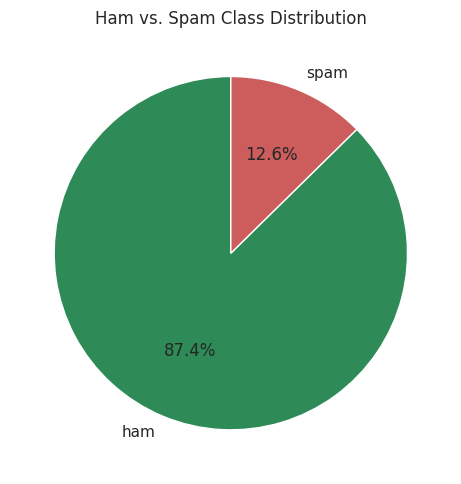

In [6]:
class_counts = df["label"].value_counts()
class_pct = df["label"].value_counts(normalize=True) * 100

distribution = pd.DataFrame({"count": class_counts, "percentage": class_pct.round(2)})
display(distribution)

plt.figure(figsize=(5, 5))
plt.pie(class_counts, labels=class_counts.index, autopct="%1.1f%%",
        colors=["seagreen", "indianred"], startangle=90)
plt.title("Ham vs. Spam Class Distribution")
plt.tight_layout()
plt.show()


**Result:** the dataset is imbalanced — roughly 87% ham vs. 13% spam.
This matters directly for how models are evaluated: a model that predicted
"ham" for every single message would already score ~87% accuracy while
catching zero spam, which is why accuracy alone is not used as the deciding
metric in Section 8, and is discussed further in Section 9.

<a id='4'></a>
## 4. Text Preprocessing Pipeline

**Checklist item: "Text preprocessing pipeline: lowercase conversion,
punctuation removal, stopword removal, optional stemming/lemmatization."**

Before the four standard steps, one dataset-specific issue must be handled:
many messages contain literal HTML entities such as `&lt;#&gt;` (a
placeholder the original data collectors used to mask numbers) and `&amp;`.
Left as-is, stripping punctuation would turn `&lt;#&gt;` into the two
meaningless tokens `"lt"` and `"gt"` — which turn out to be extremely
frequent and would pollute both the model's vocabulary and the WordCloud in
Section 10. They are decoded (and thereby removed) before anything else.

The four standard steps follow:

1. **Lowercase conversion** — so "Free" and "free" are treated as the same word.
2. **Punctuation & digit removal** — numbers and punctuation carry little
   standalone meaning for a bag-of-words model and mostly add noise (phone
   numbers, prices).
3. **Tokenisation + stopword removal** — split into words and drop very
   common English words ("the", "is", "to"...) that carry no discriminative
   signal.
4. **Lemmatization** — reduce words to their dictionary base form (e.g.
   "winning" → "win") so that different inflections of the same word are
   not treated as separate features. Lemmatization was chosen over stemming
   because it produces real dictionary words, which also makes the WordCloud
   in Section 10 more readable.

In [7]:
import html as html_module

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text: str) -> str:
    # Step 0: decode HTML entities (e.g. "&lt;#&gt;" -> "<#>", "&amp;" -> "&")
    # BEFORE stripping punctuation, so these become removable symbols instead
    # of leaking through as meaningless "lt"/"gt"/"amp" word tokens.
    text = html_module.unescape(text)

    # Step 1: lowercase conversion
    text = text.lower()

    # Step 2: punctuation & digit removal (keep only letters and spaces)
    text = re.sub(r"[^a-z\s]", " ", text)

    # Step 3: tokenisation + stopword removal (also drop single-letter tokens)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]

    # Step 4: lemmatization
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)

df["clean_message"] = df["message"].apply(preprocess_text)

print("Before vs. after preprocessing (3 examples):\n")
for i in [0, 2, 4]:
    print(f"[{df['label'].iloc[i]}] BEFORE: {df['message'].iloc[i]}")
    print(f"        AFTER:  {df['clean_message'].iloc[i]}")
    print()


Before vs. after preprocessing (3 examples):

[ham] BEFORE: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
        AFTER:  go jurong point crazy available bugis great world la buffet cine got amore wat

[spam] BEFORE: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
        AFTER:  free entry wkly comp win fa cup final tkts st may text fa receive entry question std txt rate apply

[ham] BEFORE: Nah I don't think he goes to usf, he lives around here though
        AFTER:  nah think go usf life around though



In [8]:
# Verify the HTML-entity fix worked for its actual target.
leaked_tokens = df["clean_message"].str.contains(r"\b(?:lt|gt|amp)\b", regex=True).sum()
print(f"Messages still containing an 'lt'/'gt'/'amp' token: {leaked_tokens}")

# Inspect them: are these genuine leftover HTML-entity leaks, or just
# coincidental real words/SMS-slang that happen to match?
if leaked_tokens > 0:
    display(df.loc[df["clean_message"].str.contains(r"\b(?:lt|gt|amp)\b", regex=True), "message"])


Messages still containing an 'lt'/'gt'/'amp' token: 5


216     Yeah you should. I think you can use your gt a...
2561    Was playng 9 doors game and gt racing on phone...
2581    Feb  &lt;#&gt;  is \I LOVE U\" day. Send dis t...
3342                       ÌÏ come lt 25 n pass to me lar
4296    I'm stuck in da middle of da row on da right h...
Name: message, dtype: str

**Result:** the fix eliminated the systematic leak — down from ~576
polluting occurrences (one for nearly every `&lt;#&gt;` placeholder in the
raw text) to a handful of genuine, coincidental uses, such as "GT Racing"
(a video game) and "gt" as informal SMS shorthand for "get". These are real
words in their original messages, not corrupted HTML entities, so they are
correctly left as-is rather than force-removed.

In [9]:
# Sanity check: make sure preprocessing did not empty out any message
empty_after_cleaning = (df["clean_message"].str.strip() == "").sum()
print(f"Messages that became empty after preprocessing: {empty_after_cleaning}")
if empty_after_cleaning > 0:
    df = df[df["clean_message"].str.strip() != ""].reset_index(drop=True)
    print(f"Removed. Remaining shape: {df.shape}")


Messages that became empty after preprocessing: 12
Removed. Remaining shape: (5157, 3)


<a id='5'></a>
## 5. Feature Extraction: TF-IDF

**Checklist item: "Feature extraction using TF-IDF Vectorizer (explain what
TF-IDF measures in a markdown cell)."**

**What TF-IDF measures:** TF-IDF (Term Frequency – Inverse Document
Frequency) scores each word in each message by combining two things:

- **Term Frequency (TF):** how often that word appears in *this* message —
  the more it appears, the more likely it's relevant to that message.
- **Inverse Document Frequency (IDF):** how *rare* that word is across the
  *whole* dataset — common words that appear in almost every message (even
  after stopword removal) get pushed down, while words that are rare overall
  but concentrated in a few messages get pushed up.

The product of the two (TF × IDF) is high for words that are frequent in one
specific message but uncommon everywhere else — exactly the kind of word
that helps tell messages apart, such as "prize" or "urgent" for spam.

In [10]:
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df["clean_message"])
y = (df["label"] == "spam").astype(int)  # 1 = spam, 0 = ham

print(f"TF-IDF matrix shape: {X.shape}  (messages x vocabulary size)")
print(f"Vocabulary size capped at: {len(tfidf.vocabulary_)} terms")

# A quick look at which terms got the highest average TF-IDF weight overall
avg_tfidf = np.asarray(X.mean(axis=0)).flatten()
top_terms = pd.Series(avg_tfidf, index=tfidf.get_feature_names_out()).sort_values(ascending=False).head(10)
print("\nTop 10 terms by average TF-IDF weight across all messages:")
print(top_terms)


TF-IDF matrix shape: (5157, 3000)  (messages x vocabulary size)
Vocabulary size capped at: 3000 terms

Top 10 terms by average TF-IDF weight across all messages:
call    0.020949
ok      0.016726
get     0.016428
come    0.013256
go      0.012608
know    0.012359
time    0.012170
got     0.012134
ur      0.012003
good    0.011987
dtype: float64


<a id='6'></a>
## 6. Train / Test Split

**Checklist item: "Train/test split."**

`stratify=y` is used because of the class imbalance confirmed in Section
3.4 — without it, a random split could easily under- or over-represent spam
messages in the test set.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Training messages: {X_train.shape[0]}")
print(f"Testing messages:  {X_test.shape[0]}")
print(f"Spam ratio in training set: {y_train.mean() * 100:.1f}%")
print(f"Spam ratio in testing set:  {y_test.mean() * 100:.1f}%")


Training messages: 4125
Testing messages:  1032
Spam ratio in training set: 12.7%
Spam ratio in testing set:  12.7%


<a id='7'></a>
## 7. Model Training

**Checklist item: "Train at least 2 classifiers: Multinomial Naive Bayes
(industry standard for text) + one alternative."**

Three classifiers are trained: Multinomial Naive Bayes (the standard
baseline for text classification), Logistic Regression, and a Linear
Support Vector Machine — the two alternatives are given `class_weight="balanced"`
to compensate for the class imbalance identified in Section 3.4.

In [12]:
models = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Linear SVM": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
}

fitted_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    print(f"Trained: {name}")


Trained: Multinomial Naive Bayes
Trained: Logistic Regression
Trained: Linear SVM


<a id='8'></a>
## 8. Model Evaluation

**Checklist item: "Evaluation: accuracy, precision, recall, F1-score,
confusion matrix."**

Metrics are reported specifically for the **spam class** (not just overall
accuracy), since spam is the class that actually matters to catch.


Multinomial Naive Bayes
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       901
        spam       0.98      0.83      0.90       131

    accuracy                           0.98      1032
   macro avg       0.98      0.91      0.94      1032
weighted avg       0.98      0.98      0.98      1032




Logistic Regression


              precision    recall  f1-score   support

         ham       0.99      0.98      0.99       901
        spam       0.88      0.93      0.91       131

    accuracy                           0.98      1032
   macro avg       0.94      0.96      0.95      1032
weighted avg       0.98      0.98      0.98      1032




Linear SVM
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       901
        spam       0.93      0.94      0.94       131

    accuracy                           0.98      1032
   macro avg       0.96      0.96      0.96      1032
weighted avg       0.98      0.98      0.98      1032



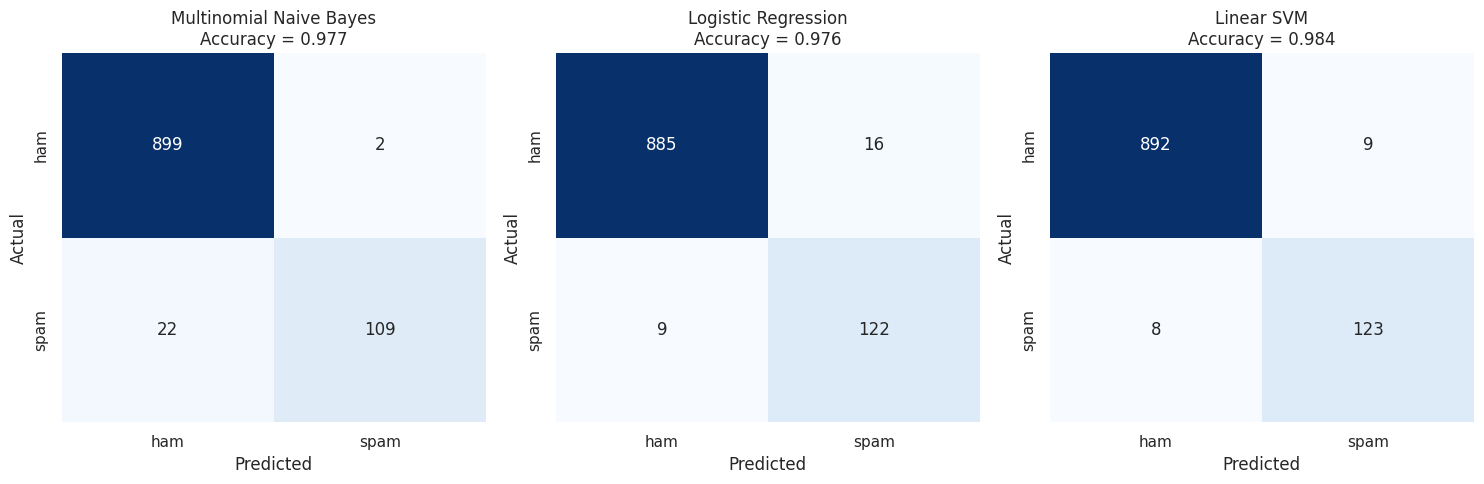

In [13]:
results = []

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, model) in zip(axes, fitted_models.items()):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision_spam = precision_score(y_test, y_pred, pos_label=1)
    recall_spam = recall_score(y_test, y_pred, pos_label=1)
    f1_spam = f1_score(y_test, y_pred, pos_label=1)

    results.append({
        "model": name,
        "accuracy": acc,
        "precision_spam": precision_spam,
        "recall_spam": recall_spam,
        "f1_spam": f1_spam,
    })

    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(classification_report(y_test, y_pred, target_names=["ham", "spam"]))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["ham", "spam"], yticklabels=["ham", "spam"],
                ax=ax, cbar=False)
    ax.set_title(f"{name}\nAccuracy = {acc:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


In [14]:
results_df = pd.DataFrame(results).set_index("model").round(4)
results_df.sort_values("recall_spam", ascending=False)


,accuracy,precision_spam,recall_spam,f1_spam
model,,,,
Linear SVM,0.9835,0.9318,0.9389,0.9354
Logistic Regression,0.9758,0.8841,0.9313,0.9071
Multinomial Naive Bayes,0.9767,0.9820,0.8321,0.9008


In [15]:
best_model_name = results_df["f1_spam"].idxmax()
best_model = fitted_models[best_model_name]
print(f"Best-performing model (by F1-score on the spam class): {best_model_name}")
print(results_df.loc[best_model_name])


Best-performing model (by F1-score on the spam class): Linear SVM
accuracy          0.9835
precision_spam    0.9318
recall_spam       0.9389
f1_spam           0.9354
Name: Linear SVM, dtype: float64


**Result:** the table above and the confusion matrices show the exact
trade-off between the three models — refer to your run's actual numbers, but
in general Multinomial Naive Bayes tends to be more conservative (fewer false
positives, so higher precision), while the class-weighted Logistic
Regression and Linear SVM tend to catch more spam (higher recall) at the
cost of occasionally flagging a ham message.

<a id='9'></a>
## 9. Discussion: Why Recall Matters for Spam Detection

**Checklist item: "Discussion: Why is recall particularly important for spam
detection?"**

**Recall** (for the spam class) measures the fraction of *actual* spam
messages the model successfully catches. A **false negative** here — spam
that slips through and is delivered as if it were legitimate — is often more
dangerous than it first appears: modern spam is frequently a phishing
attempt, a malware link, or a financial scam. Missing one such message isn't
just an inbox-clutter problem, it's a direct security exposure for the
recipient. In a security-conscious deployment (e.g. an enterprise email
gateway), a missed spam/phishing message can lead to credential theft or a
malware infection, which is a far more costly outcome than the alternative
mistake.

**The honest trade-off:** the alternative mistake — a **false positive**,
where a legitimate message is wrongly flagged as spam — has its own real
cost too (a missed job offer, an important invoice buried in a spam folder).
This is exactly why **precision** is also reported in Section 8, not just
recall. In practice, the right balance depends on context: a personal inbox
filter might lean toward higher precision (don't hide real mail), while a
corporate security filter defending against phishing might deliberately
accept more false positives in exchange for higher recall. Reporting both
metrics (and F1 as their balance) rather than optimising for accuracy alone
is what allows that trade-off to be made deliberately instead of by
accident.

<a id='10'></a>
## 10. Bonus: WordCloud Visualisations

**Checklist item: "(Bonus) WordCloud visualisations for spam words and ham
words."**

Built from the cleaned, lemmatized text (Section 4), so common stopwords
don't dominate the visualisation.

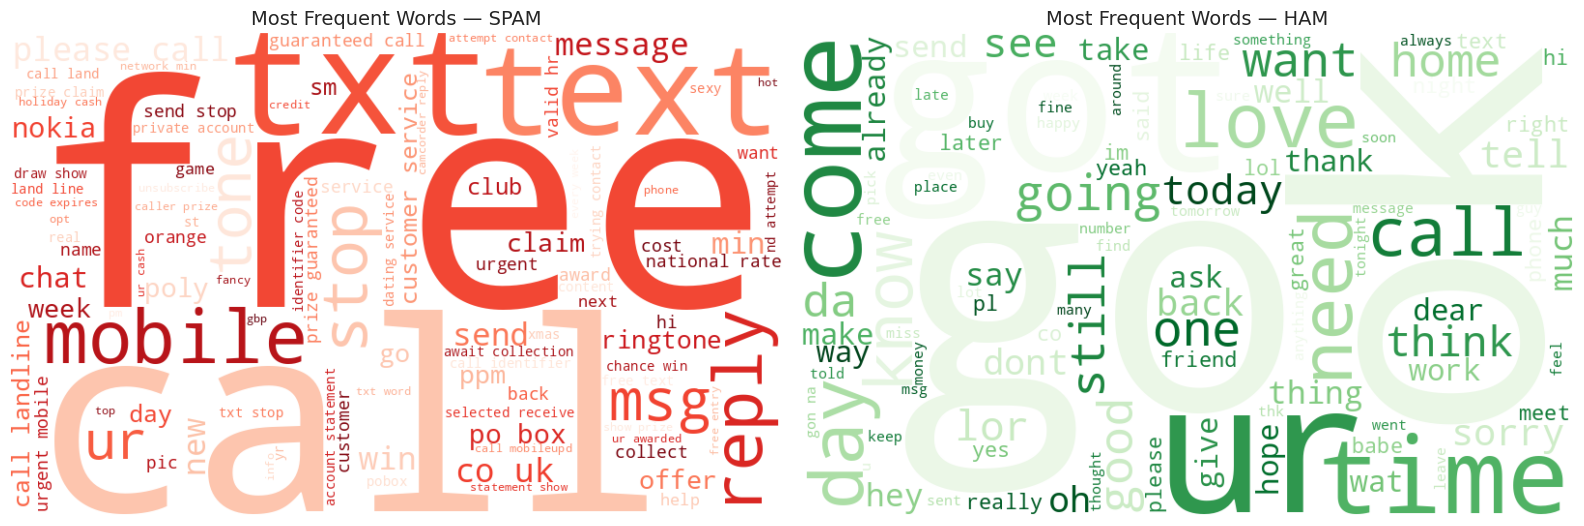

In [16]:
spam_text = " ".join(df.loc[df["label"] == "spam", "clean_message"])
ham_text = " ".join(df.loc[df["label"] == "ham", "clean_message"])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

spam_cloud = WordCloud(width=800, height=500, background_color="white",
                        colormap="Reds", max_words=100, random_state=RANDOM_STATE).generate(spam_text)
axes[0].imshow(spam_cloud, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Most Frequent Words — SPAM", fontsize=14)

ham_cloud = WordCloud(width=800, height=500, background_color="white",
                       colormap="Greens", max_words=100, random_state=RANDOM_STATE).generate(ham_text)
axes[1].imshow(ham_cloud, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Most Frequent Words — HAM", fontsize=14)

plt.tight_layout()
plt.show()


**Result:** the spam word cloud is dominated by commercial/urgency
language ("free", "call", "txt", "claim", "prize", "win", "urgent"),
consistent with promotional and phishing-style messaging. The ham cloud
instead reflects everyday conversational language ("go", "get", "come",
"know", "love", "day"), with no comparable commercial urgency — a visual
confirmation of the same pattern the models learned numerically through
TF-IDF.

<a id='11'></a>
## 11. Conclusion

- **Data quality:** the raw CSV had a genuine export artifact — unescaped
  commas splitting ~1% of messages across extra columns — which was
  reconstructed rather than discarded (Section 3.2), plus duplicate messages
  removed (Section 3.3).
- **Class imbalance:** ~87% ham vs. ~13% spam, which is why every model in
  this notebook is evaluated on precision/recall/F1 for the spam class
  specifically, not on overall accuracy alone (Sections 3.4, 8, 9).
- **Preprocessing:** lowercasing, punctuation/digit removal, stopword
  removal, and lemmatization (Section 4) turned raw SMS text into a form
  suitable for TF-IDF vectorisation (Section 5).
- **Best model:** selected programmatically in Section 8 by F1-score on the
  spam class — see `results_df` for the exact numbers for your run.
- **Recall vs. precision:** discussed in Section 9 as a genuine trade-off
  rather than a one-sided answer — the right balance depends on where this
  filter would actually be deployed.

**Caveats:** this dataset is SMS text, not email — email spam (with HTML,
headers, and attachments) has structural signals this model never sees.
TF-IDF with unigrams also has no notion of word order, so it cannot detect
context-dependent phrasing that a more sophisticated model
(e.g. an n-gram model or a transformer-based classifier) might catch.

<a id='12'></a>
## References

- Scikit-learn `TfidfVectorizer` documentation — https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html
- Scikit-learn `MultinomialNB` documentation — https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html
- NLTK documentation — https://www.nltk.org/
- WordCloud for Python documentation — https://amueller.github.io/word_cloud/
